In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
import PIL
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import pathlib

In [5]:
import os
os.environ["KAGGLE_API_TOKEN"] = "KAGGLE_API_TOKEN"

In [6]:
!kaggle datasets download -d moltean/fruits

Dataset URL: https://www.kaggle.com/datasets/moltean/fruits
License(s): CC-BY-SA-4.0
100% 6.79G/6.79G [00:33<00:00, 220MB/s] 



In [7]:
!unzip -q fruits.zip

In [8]:
!find . -maxdepth 2 -type d

.
./.config
./.config/configurations
./.config/logs
./fruits-360_meta
./fruits-360_meta/fruits-360-meta
./fruits-360_3-body-problem
./fruits-360_3-body-problem/fruits-360-3-body-problem
./fruits-360_100x100
./fruits-360_100x100/fruits-360
./fruits-360_multi
./fruits-360_multi/test-multiple_fruits
./fruits-360_original-size
./fruits-360_original-size/fruits-360-original-size
./sample_data


In [9]:
from google.colab import userdata

api_token = userdata.get('KAGGLE_API_TOKEN')
print(api_token)

KGAT_70be930a11c1d7811ab002898dd5a605


In [10]:
import os

os.listdir("/content/fruits-360_100x100/fruits-360")

['README.md', 'Test', 'LICENSE', 'Training']

In [11]:
train_dir = "/content/fruits-360_100x100/fruits-360/Training"
test_dir = "/content/fruits-360_100x100/fruits-360/Test"

In [12]:
print(train_dir)

/content/fruits-360_100x100/fruits-360/Training


In [13]:
train_dir = pathlib.Path(train_dir)
test_dir = pathlib.Path(test_dir)
print(train_dir)

/content/fruits-360_100x100/fruits-360/Training


In [14]:
class_names = os.listdir(train_dir)

print("Number of classes:", len(class_names))
print(class_names[:10])

Number of classes: 260
['Ginger 2', 'Apple 14', 'Apple Granny Smith 1', 'Banana Lady Finger 1', 'Cabbage white 1', 'Apple 23', 'Cantaloupe 1', 'Apple Red 1', 'Cherry Wax Red 1', 'Pear 10']


In [15]:
import os
import shutil

In [16]:
original_train = "/content/fruits-360_100x100/fruits-360/Training"
original_test = "/content/fruits-360_100x100/fruits-360/Test"

In [17]:
new_train = "/content/my_fruits/Training"
new_test = "/content/my_fruits/Test"

os.makedirs(new_train, exist_ok=True)
os.makedirs(new_test, exist_ok=True)

In [18]:
selected_classes = [
    "Apple Granny Smith 1",
    "Banana 1",
    "Orange 1",
    "Mango 1",
    "Kiwi 1",
    "Pineapple 1",
    "Strawberry 1",
    "Watermelon 1"
]

In [19]:
for cls in selected_classes:
    shutil.copytree(
        os.path.join(original_train, cls),
        os.path.join(new_train, cls)
    )

    shutil.copytree(
        os.path.join(original_test, cls),
        os.path.join(new_test, cls)
    )

print("Dataset created successfully!")

Dataset created successfully!


In [20]:
print(os.listdir(new_train))

['Apple Granny Smith 1', 'Kiwi 1', 'Banana 1', 'Strawberry 1', 'Orange 1', 'Pineapple 1', 'Watermelon 1', 'Mango 1']


In [21]:
data_dir="/content/my_fruits/Training"

In [22]:
batch_size=32
img_height=100
img_width=100

In [23]:
train_ds=tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height,img_width),
    batch_size=batch_size
)

Found 3874 files belonging to 8 classes.
Using 3100 files for training.


In [24]:
test_ds=tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height,img_width),
    batch_size=batch_size
)

Found 3874 files belonging to 8 classes.
Using 774 files for validation.


In [25]:
class_names=train_ds.class_names
print(class_names)

['Apple Granny Smith 1', 'Banana 1', 'Kiwi 1', 'Mango 1', 'Orange 1', 'Pineapple 1', 'Strawberry 1', 'Watermelon 1']


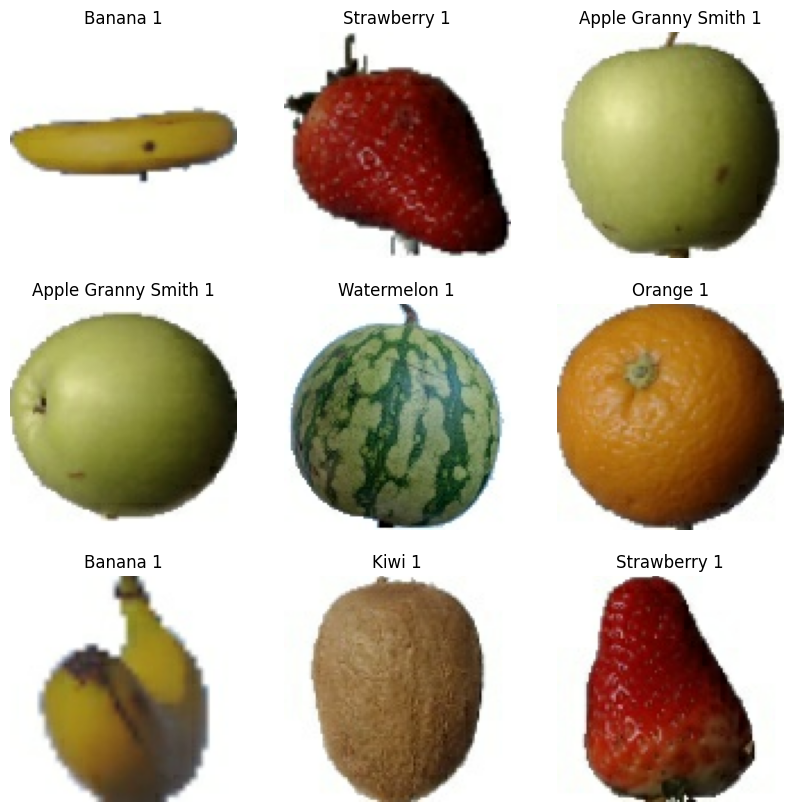

In [26]:
plt.figure(figsize=(10,10))
for image, label in train_ds.take(1):
  for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(image[i].numpy().astype('uint8'))
    plt.title(class_names[label[i]])
    plt.axis('off')
  plt.show()

In [27]:
auto=tf.data.AUTOTUNE
train_ds_nm=train_ds.cache().shuffle(1000).prefetch(buffer_size=auto)
test_ds_nm=test_ds.cache().prefetch(buffer_size=auto)

In [28]:
normalization_layer=layers.Rescaling(1./255)

In [29]:
norm_train_ds=train_ds_nm.map(lambda x,y:(normalization_layer(x),y))
norm_test_ds=test_ds_nm.map(lambda x,y:(normalization_layer(x),y))
image_batch, labels_batch = next(iter(norm_train_ds))
first_image = image_batch[0]
print(np.min(first_image), np.max(first_image))

0.0 1.0


In [30]:
data_augmentation=keras.Sequential([
    layers.RandomFlip("horizontal",input_shape=(img_height,img_width,3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])
num_classes = len(class_names)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [31]:
def build_model():
  model=Sequential([
      data_augmentation,
      layers.Conv2D(16,3,padding='same',activation='relu'),
      layers.MaxPooling2D(),
      layers.Conv2D(32,3,padding='same',activation='relu'),
      layers.MaxPooling2D(),
      layers.Conv2D(64,3,padding='same',activation='relu'),
      layers.MaxPooling2D(),
      layers.Dropout(0.2),
      layers.Flatten(),
      layers.Dense(128,activation='relu'),
      layers.Dense(num_classes)
  ])
  model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])
  return model

In [32]:
class printdot(keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs):
    if epoch%100==0: print(" ")
    print(".", end=" ")
model=build_model()
early_stop=keras.callbacks.EarlyStopping(monitor="val_loss", patience=50)
history = model.fit(norm_train_ds, validation_data=norm_test_ds,epochs=200, verbose=0, callbacks=[early_stop, printdot()])

 
. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .  
. . . . . . . . . . . . . . . 

In [40]:
hist=pd.DataFrame(history.history)
hist.epoch=history.epoch
hist.tail()

/tmp/ipykernel_912/3156515917.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  hist.epoch=history.epoch


,accuracy,loss,val_accuracy,val_loss
110,1.0,0.000038,1.0,0.000006
111,1.0,0.000020,1.0,0.000005
112,1.0,0.000021,1.0,0.000005
113,1.0,0.000024,1.0,0.000004
114,1.0,0.000020,1.0,0.000004


In [33]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 100, 100, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,613,178 (13.78 MB)

 Trainable params: 1,204,392 (4.59 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,408,786 (9.19 MB)

In [41]:
test_dir = "/content/my_fruits/Test"

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(100, 100),
    batch_size=32,
    shuffle=False
)

Found 1299 files belonging to 8 classes.


In [42]:
model.evaluate(test_ds)

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7698 - loss: 281.5409


[281.5409240722656, 0.7698229551315308]

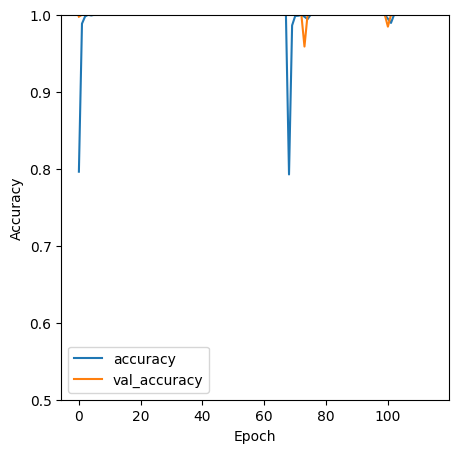

In [43]:
plt.figure(figsize=(5, 5))
plt.plot(hist['accuracy'], label='accuracy')
plt.plot(hist['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend()

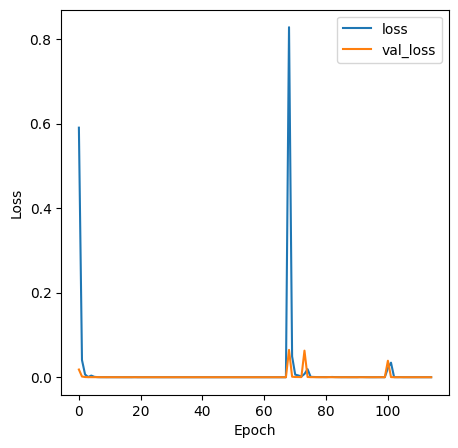

In [44]:
plt.figure(figsize=(5, 5))
plt.plot(hist['loss'], label='loss')
plt.plot(hist['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

In [46]:
img=tf.keras.utils.load_img("Banana-Single.jpg",target_size=(100,100))
img_array=tf.keras.utils.img_to_array(img)
img_array=tf.expand_dims(img_array,0)

In [48]:
prediction = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step


In [49]:
predicted_class = class_names[np.argmax(prediction)]
print(predicted_class)

Banana 1


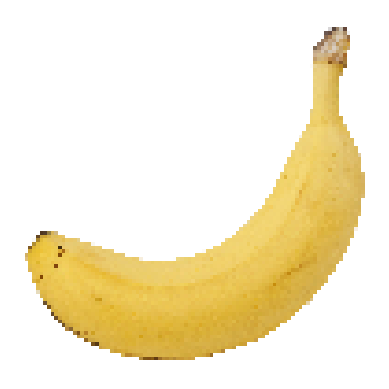

In [50]:
plt.imshow(img)
plt.axis("off")
plt.show()